In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
import os

# Find where Kaggle put your data files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/saifrehman63/titanic-dataset/train.csv
/kaggle/input/datasets/saifrehman63/titanic-dataset/test.csv
/kaggle/input/datasets/saifrehman63/titanic-dataset/gender_submission.csv
/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [3]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

test_ids = test['PassengerId'].copy()  # save for submission later
dfs = [train, test]                    # process both together

print(f'Train: {train.shape}')
print(f'Test : {test.shape}')
train.head()

Train: (891, 12)
Test : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
print(pd.DataFrame({'count': missing, 'pct%': missing_pct})[missing > 0])

          count  pct%
Age         177  19.9
Cabin       687  77.1
Embarked      2   0.2


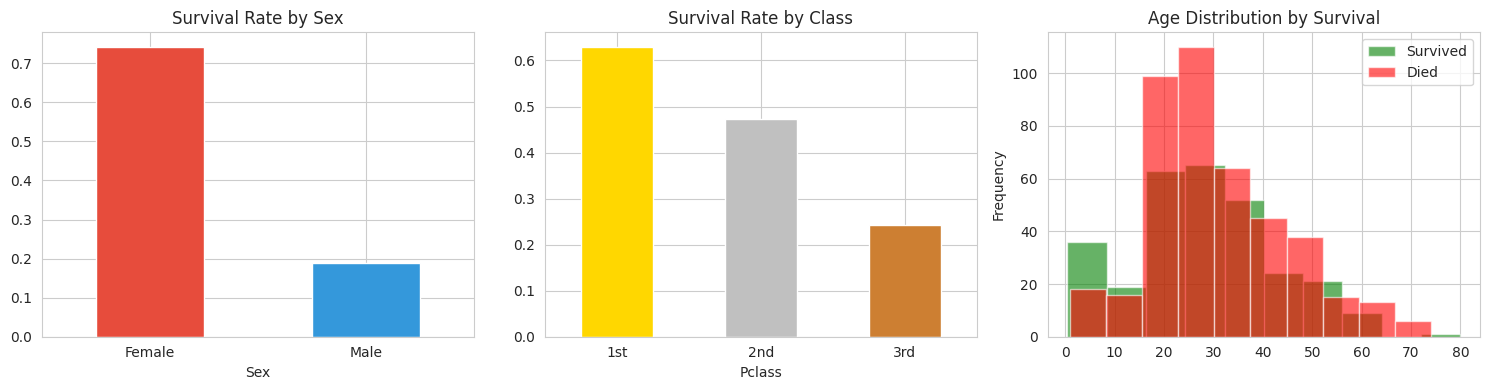

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#3498db'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

train.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['gold','silver','#cd7f32'])
axes[1].set_title('Survival Rate by Class')
axes[1].set_xticklabels(['1st','2nd','3rd'], rotation=0)

train[train['Survived']==1]['Age'].dropna().plot(
    kind='hist', ax=axes[2], alpha=0.6, label='Survived', color='green')
train[train['Survived']==0]['Age'].dropna().plot(
    kind='hist', ax=axes[2], alpha=0.6, label='Died', color='red')
axes[2].set_title('Age Distribution by Survival')
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
# We apply everything to both train and test at once
for df in dfs:

    # Title — extracted from Name (e.g. "Braund, Mr. Owen" → "Mr")
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
    rare = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
    df['Title'] = df['Title'].replace(rare, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # Is travelling alone?
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Cabin recorded at all? (proxy for wealth)
    df['HasCabin'] = df['Cabin'].notna().astype(int)

print('Feature engineering done ✅')
print(train[['Name','Title','FamilySize','IsAlone','HasCabin']].head(6))

Feature engineering done ✅
                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   
5                                   Moran, Mr. James    Mr           1   

   IsAlone  HasCabin  
0        0         0  
1        0         1  
2        1         0  
3        0         1  
4        1         0  
5        1         0  


In [7]:
for df in dfs:

    # Age: fill with median age of passengers sharing the same Title
    age_medians = train.groupby('Title')['Age'].median()
    df['Age'] = df.apply(
        lambda row: age_medians[row['Title']] if pd.isnull(row['Age']) else row['Age'],
        axis=1
    )

    # Fare: fill with median fare for that Pclass
    df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

    # Embarked: fill with most common port
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Bin Age and Fare into groups (children / young adult / adult / senior…)
    df['AgeBand']  = pd.cut(df['Age'],  bins=[0,12,18,35,60,100],
                            labels=[0,1,2,3,4]).astype(int)
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=[0,1,2,3]).astype(int)

print('Missing values handled ✅')
print('Nulls left in train:', train.isnull().sum().sum())
print('Nulls left in test :', test.isnull().sum().sum())

Missing values handled ✅
Nulls left in train: 687
Nulls left in test : 327


In [8]:
le = LabelEncoder()

for df in dfs:
    df['Sex']      = le.fit_transform(df['Sex'])       # female=0, male=1
    df['Embarked'] = le.fit_transform(df['Embarked'])  # C=0, Q=1, S=2
    df['Title']    = le.fit_transform(df['Title'])     # integer per title

print('Encoding done ✅')
train[['Sex','Embarked','Title']].head()

Encoding done ✅


,Sex,Embarked,Title
0,1,2,2
1,0,0,3
2,0,2,1
3,0,2,3
4,1,2,2


In [9]:
FEATURES = ['Pclass', 'Sex', 'AgeBand', 'FareBand',
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin']

X      = train[FEATURES]
y      = train['Survived']
X_test = test[FEATURES]

print('X shape:', X.shape)
X.head()

X shape: (891, 9)


,Pclass,Sex,AgeBand,FareBand,Embarked,Title,FamilySize,IsAlone,HasCabin
0,3,1,2,0,2,2,2,0,0
1,1,0,3,3,0,3,2,0,1
2,3,0,2,1,2,1,1,1,0
3,1,0,2,3,2,3,2,0,1
4,3,1,2,1,2,2,1,1,0


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                        learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name:28s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

Logistic Regression           mean=0.8058  std=0.0203
Random Forest                 mean=0.8305  std=0.0112
Gradient Boosting             mean=0.8283  std=0.0162


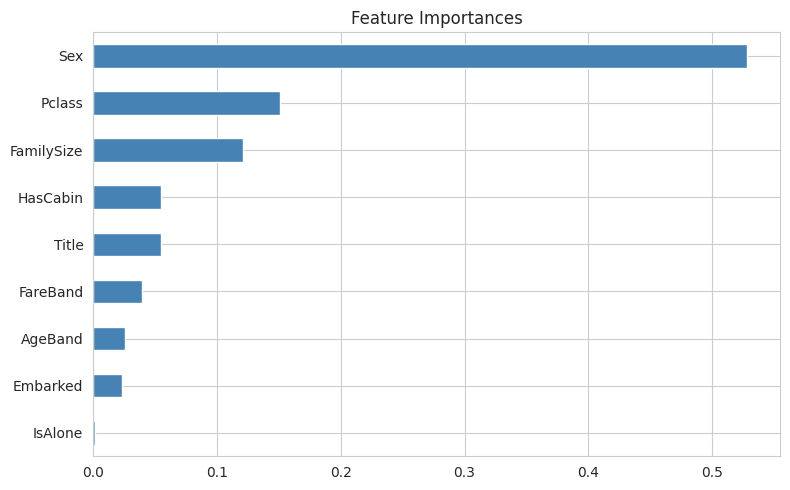

In [11]:
# Train the best model first to inspect feature importances
best_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
best_model.fit(X, y)

pd.Series(best_model.feature_importances_, index=FEATURES)\
  .sort_values()\
  .plot(kind='barh', color='steelblue', figsize=(8,5))
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In [12]:
predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived'   : predictions
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved ✅')
print(f'Predicted {predictions.sum()} survivors out of {len(predictions)} passengers')
submission.head(10)

submission.csv saved ✅
Predicted 150 survivors out of 418 passengers


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
